###This project explores a real estate dataset from Saudi Arabia to understand the factors that influence property prices. The goal is to analyze the dataset using Exploratory Data Analysis (EDA) and later build a machine learning model to predict property prices based on property features.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [64]:
df = pd.read_csv("SA_Aqar.csv")

In [65]:
df.head()

,city,district,front,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,...,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price,details
0,الرياض,حي العارض,شمال,250,0,5,5,1,1,1,...,0,0,1,0,1,1,0,0,80000,للايجار فيلا دبلكس في موقع ممتاز جدا بالقرب من...
1,الرياض,حي القادسية,جنوب,370,0,4,5,2,1,1,...,0,0,1,0,0,1,0,0,60000,*** فيلا درج مع الصالة جديدة ***\n\nعبارة عن م...
2,الرياض,حي القادسية,جنوب,380,0,4,5,1,1,1,...,1,0,1,0,0,1,0,0,60000,فيلا للايجار درج داخلي مشب خارجي مجلس مقلط وصا...
3,الرياض,حي المعيزلة,غرب,250,0,5,5,3,0,1,...,0,0,1,0,0,0,0,0,55000,فيلا للايجار جديده لن تستخدم ش...
4,الرياض,حي العليا,غرب,400,11,7,5,2,1,1,...,1,0,1,0,1,1,0,0,70000,فيلا للايجار حي العليا \n\nالارضي مجالس وغرفتي...


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3718 entries, 0 to 3717
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   city          3718 non-null   object
 1   district      3718 non-null   object
 2   front         3718 non-null   object
 3   size          3718 non-null   int64 
 4   property_age  3718 non-null   int64 
 5   bedrooms      3718 non-null   int64 
 6   bathrooms     3718 non-null   int64 
 7   livingrooms   3718 non-null   int64 
 8   kitchen       3718 non-null   int64 
 9   garage        3718 non-null   int64 
 10  driver_room   3718 non-null   int64 
 11  maid_room     3718 non-null   int64 
 12  furnished     3718 non-null   int64 
 13  ac            3718 non-null   int64 
 14  roof          3718 non-null   int64 
 15  pool          3718 non-null   int64 
 16  frontyard     3718 non-null   int64 
 17  basement      3718 non-null   int64 
 18  duplex        3718 non-null   int64 
 19  stairs

###The dataset contains 3718 property listings and 24 features describing different aspects of the properties.

In [67]:
df.describe()

,size,property_age,bedrooms,bathrooms,livingrooms,kitchen,garage,driver_room,maid_room,furnished,ac,roof,pool,frontyard,basement,duplex,stairs,elevator,fireplace,price
count,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3718.000000,3.718000e+03
mean,390.968531,5.064820,5.083916,4.606509,2.243948,0.909360,0.802044,0.495697,0.795320,0.123453,0.560785,0.521517,0.162453,0.802582,0.034158,0.499462,0.814416,0.080958,0.181280,8.738797e+04
std,1565.056135,7.590427,1.230040,0.703449,0.916436,0.287135,0.398512,0.500049,0.403522,0.329001,0.496358,0.499604,0.368915,0.398104,0.181660,0.500067,0.388823,0.272807,0.385302,7.063470e+04
min,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+03
25%,280.000000,0.000000,4.000000,4.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,5.500000e+04
50%,330.000000,2.000000,5.000000,5.000000,2.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,7.000000e+04
75%,400.000000,7.000000,6.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000e+05
max,95000.000000,36.000000,7.000000,5.000000,5.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.700000e+06


In [68]:
df.isnull().sum()

,0
city,0
district,0
front,0
size,0
property_age,0
bedrooms,0
bathrooms,0
livingrooms,0
kitchen,0
garage,0


###Most columns have no missing values. The details column contains some missing values because it stores text descriptions, and it will not be used in the model.

In [69]:
df.duplicated().sum()
df = df.drop_duplicates()

###Some duplicate rows were detected in the dataset. These duplicates will be removed to avoid bias in the analysis and model training.

In [70]:
df = df.drop(['details'], axis=1, errors='ignore')

In [71]:
df.columns

Index(['city', 'district', 'front', 'size', 'property_age', 'bedrooms',
       'bathrooms', 'livingrooms', 'kitchen', 'garage', 'driver_room',
       'maid_room', 'furnished', 'ac', 'roof', 'pool', 'frontyard', 'basement',
       'duplex', 'stairs', 'elevator', 'fireplace', 'price'],
      dtype='object')

In [72]:
df.nunique()

,0
city,4
district,174
front,10
size,199
property_age,36
bedrooms,7
bathrooms,5
livingrooms,5
kitchen,2
garage,2


###The dataset contains different types of features. Some features are binary variables with values 0 and 1, indicating the presence of property amenities such as garage, pool, and elevator. Other features such as city, district, and front are categorical variables with multiple categories. Additionally, numerical variables such as size, property_age, and price contain many unique values representing continuous property characteristics.

In [73]:
df["price"].describe()

,price
count,1.521000e+03
mean,9.950328e+04
std,9.632974e+04
min,1.000000e+03
25%,5.200000e+04
50%,8.000000e+04
75%,1.200000e+05
max,1.700000e+06


###The average property price in the dataset is around 99,503. Most properties have prices between 52,000 and 120,000. However, the maximum price reaches 1,700,000, which suggests the presence of potential outliers in the dataset.

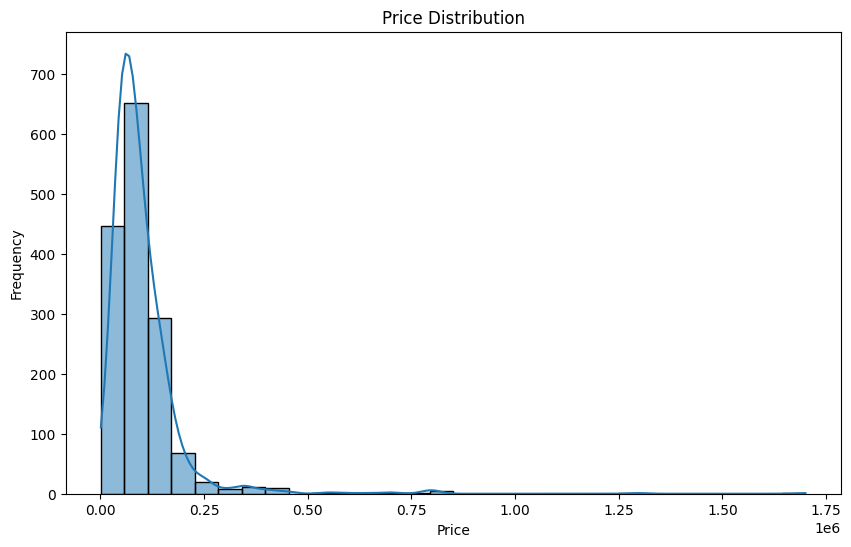

In [74]:
plt.figure(figsize=(10, 6))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

###The histogram with KDE shows that the price distribution is right-skewed. Most property prices are concentrated between approximately 50,000 and 120,000, while a small number of properties have significantly higher prices, creating a long tail on the right side of the distribution.

Text(0.5, 1.0, 'Price Distribution')

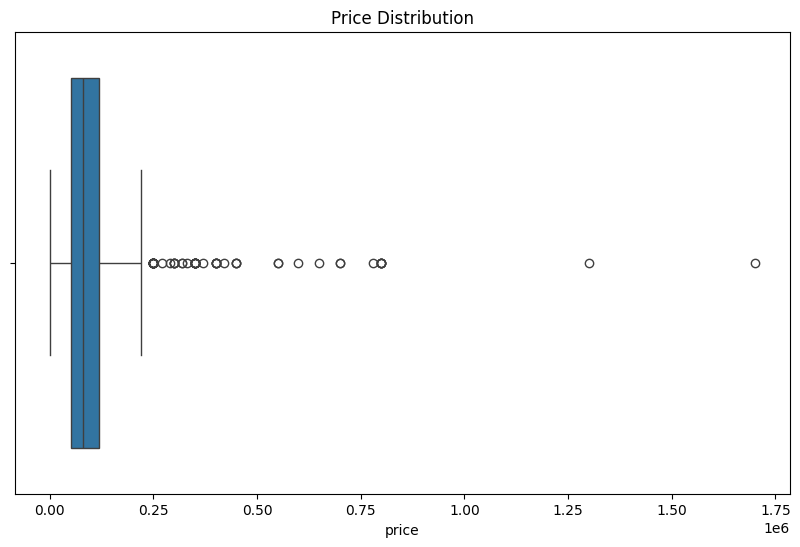

In [75]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["price"])
plt.title("Price Distribution")


###Although several outliers appear in the price distribution, they were not removed because they may represent luxury properties with legitimately high prices.

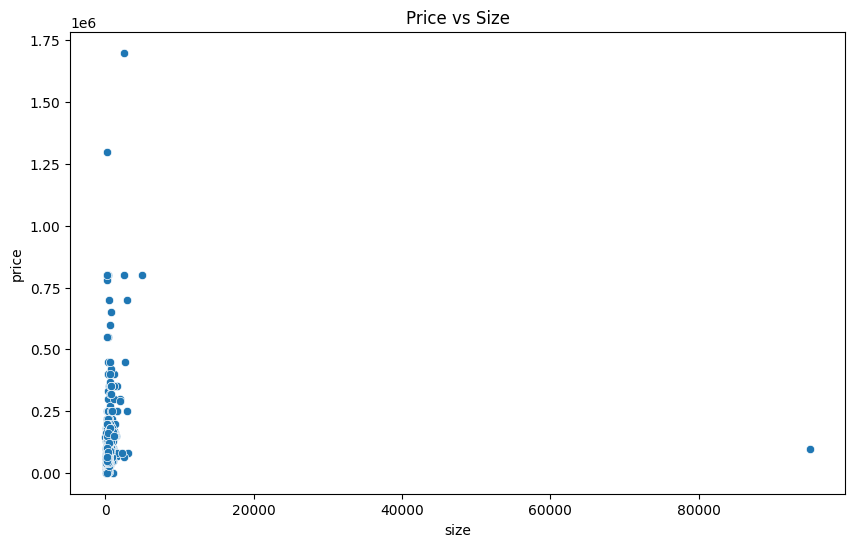

In [76]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="size", y="price", data=df)
plt.title("Price vs Size")
plt.xlabel("size")
plt.ylabel("price")
plt.show()


###An extremely large value was detected in the size feature (around 90,000), which is unrealistic for residential properties. This value was considered a data entry error and removed to improve the quality of the dataset.

In [77]:
df = df[df["size"] < 10000]
df = df[df["price"] < 300000]
df.shape

(1479, 23)

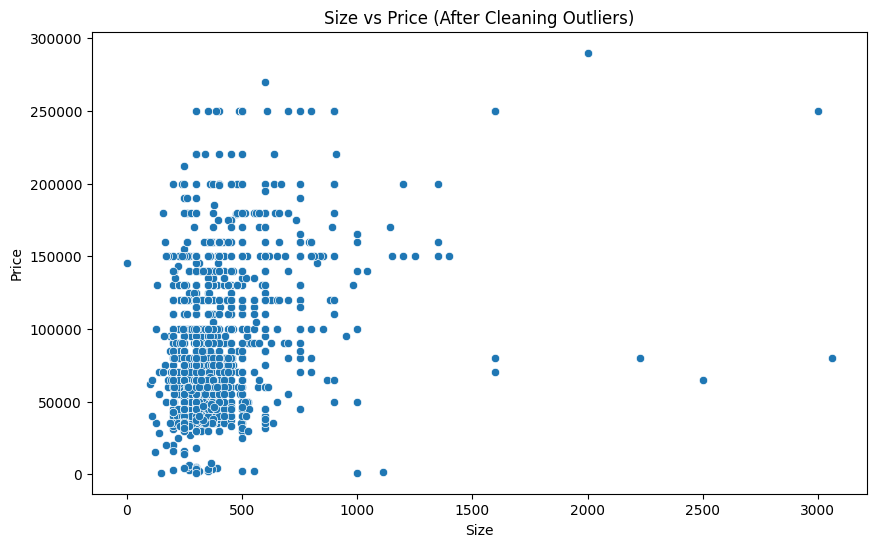

In [78]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="size", y="price", data=df)
plt.title("Size vs Price (After Cleaning Outliers)")
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

###The scatter plot shows a positive relationship between property size and price.
# As the size increases, the price generally increases as well.
# Most properties are concentrated between 200–800 in size and 40,000–150,000 in price.
# There are a few larger properties, but they are less common.

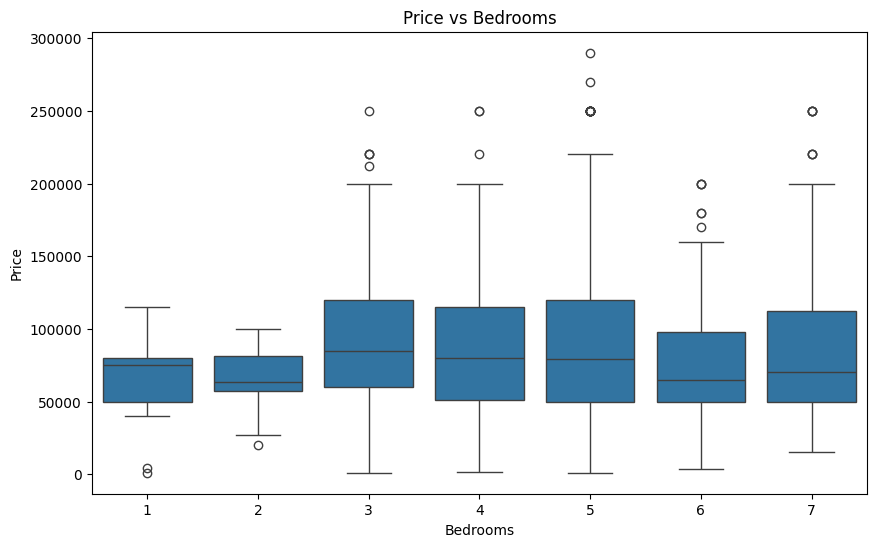

In [79]:
plt.figure(figsize=(10,6))
sns.boxplot(x="bedrooms", y="price", data=df)
plt.title("Price vs Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

###Properties with more bedrooms tend to have higher prices.Most houses with 3–5 bedrooms are priced between 60k and 120k.
##However, price variation suggests other factors also affect property prices.

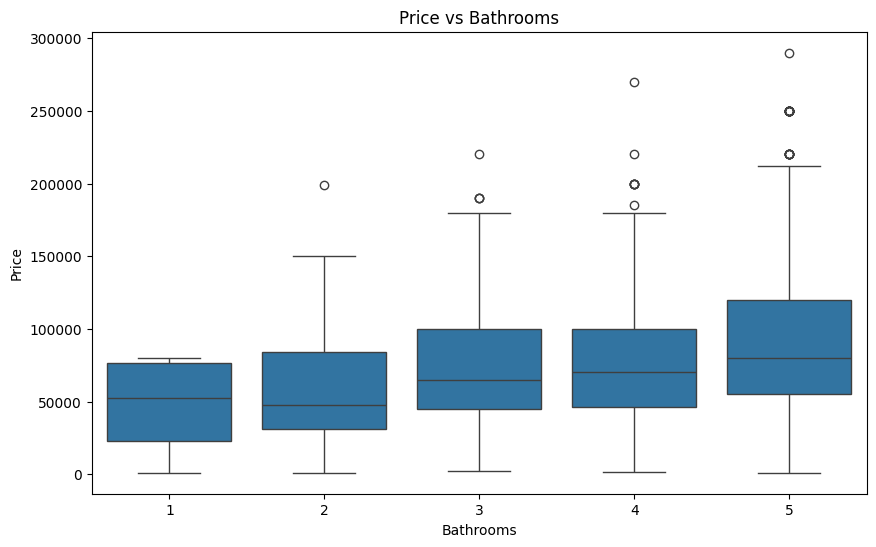

In [80]:
plt.figure(figsize=(10,6))
sns.boxplot(x="bathrooms", y="price", data=df)
plt.title("Price vs Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()

###Houses with more bathrooms generally have higher prices. Properties with 3–5 bathrooms tend to be more expensive than those with fewer bathrooms.

In [81]:
corr_price = df.corr(numeric_only=True)["price"].sort_values(ascending=False)
corr_price

,price
price,1.000000
driver_room,0.402585
ac,0.383236
size,0.326513
livingrooms,0.323456
pool,0.281208
maid_room,0.271811
basement,0.259588
elevator,0.165317
bathrooms,0.145639


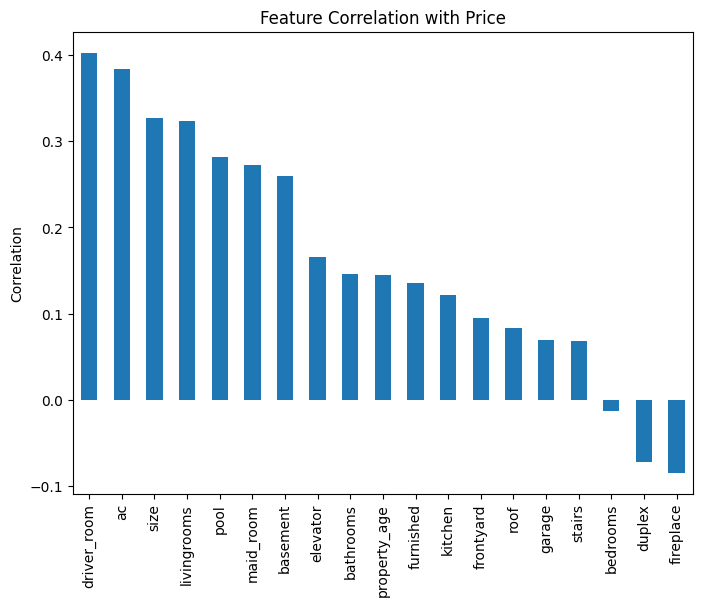

In [82]:
plt.figure(figsize=(8,6))
corr_price.drop("price").plot(kind="bar")
plt.title("Feature Correlation with Price")
plt.ylabel("Correlation")
plt.show()

###Driver room, air conditioning, property size, and number of living rooms show the strongest positive correlation with price.
Features such as duplex and fireplace have weak or slightly negative correlation with property prices.

In [83]:
df = pd.get_dummies(df, drop_first=True)

In [84]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [85]:
df.columns

Index(['size', 'property_age', 'bedrooms', 'bathrooms', 'livingrooms',
       'kitchen', 'garage', 'driver_room', 'maid_room', 'furnished',
       ...
       'district_   حي منفوحة الجديدة ', 'front_4 شوارع', 'front_جنوب',
       'front_جنوب شرقي', 'front_جنوب غربي', 'front_شرق', 'front_شمال',
       'front_شمال شرقي', 'front_شمال غربي', 'front_غرب'],
      dtype='object', length=205)

In [86]:
df = df.drop(columns=df.filter(like="district_").columns)

In [87]:
df.columns

Index(['size', 'property_age', 'bedrooms', 'bathrooms', 'livingrooms',
       'kitchen', 'garage', 'driver_room', 'maid_room', 'furnished', 'ac',
       'roof', 'pool', 'frontyard', 'basement', 'duplex', 'stairs', 'elevator',
       'fireplace', 'price', 'city_ الدمام', 'city_ الرياض', 'city_ جدة',
       'front_4 شوارع', 'front_جنوب', 'front_جنوب شرقي', 'front_جنوب غربي',
       'front_شرق', 'front_شمال', 'front_شمال شرقي', 'front_شمال غربي',
       'front_غرب'],
      dtype='object')

In [88]:
df.shape

(1479, 32)

###PART 2 ML


In [89]:
X = df.drop("price", axis=1)
y = df["price"]

In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [91]:
X_train.shape, X_test.shape

((1183, 31), (296, 31))

In [92]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [93]:
y_pred = model.predict(X_test)

In [94]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 1517253012.1510897
R2 Score: 0.34993845970688753


In [95]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [96]:
y_pred_rf = rf.predict(X_test)

In [97]:
from sklearn.metrics import mean_squared_error, r2_score

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 1462088661.438033
Random Forest R2: 0.37357342533661997


###The analysis showed that property size, driver room availability, air conditioning, and property age have the strongest influence on house prices.
Among the tested models, Random Forest slightly outperformed Linear Regression with an R² score of about 0.37, indicating a moderate ability to capture price patterns in the dataset.

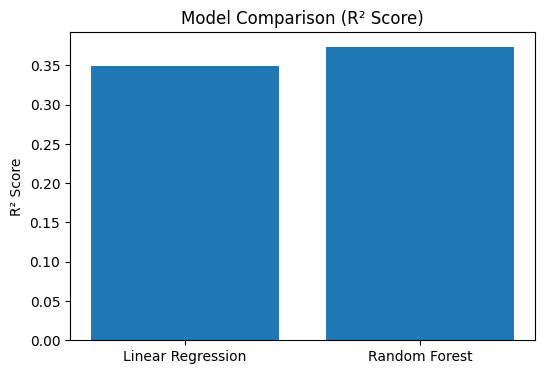

In [98]:
models = ["Linear Regression", "Random Forest"]
scores = [r2, r2_rf]

plt.figure(figsize=(6,4))
plt.bar(models, scores)
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

###Random Forest performed slightly better than Linear Regression, achieving a higher R² score and showing a better ability to model the relationship between property features and price.

In [99]:
import joblib
joblib.dump(rf, "house_model.pkl")

['house_model.pkl']

In [100]:
from google.colab import files
files.download("house_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>